# Drug Shortage Risk Analysis and Decision Support System

## Exploratory Data Analysis (EDA)

This notebook performs Exploratory Data Analysis (EDA) on the
Drugs@FDA and FDA Drug Shortages datasets.

The main objectives of the analysis are:

- Examine the structure and scope of both datasets
- Analyze data types and missing values
- Check duplicate and unique values
- Examine the distribution of drug shortage records
- Analyze the temporal distribution of shortage records
- Examine common identifier fields between the datasets
- Evaluate the potential integration of the two datasets
- Identify data preparation requirements for subsequent risk
  prediction and decision-support system development

## 1. Libraries and Data Loading

This section imports the Python libraries required for the analysis
and loads the Drugs@FDA and Drug Shortages JSON datasets.

The datasets are stored in the `datasets/` directory.

In [45]:
import json
import pandas as pd
import matplotlib.pyplot as plt

## 1. Load the Datasets

The analysis uses two FDA datasets:

- **Drugs@FDA**: information about FDA-approved human drug products.
- **Drug Shortages**: records related to drug shortage situations.

The JSON files are stored in the `Datasets` folder.

In [46]:
DRUGS_FILE = "../Datasets/drugs.json"
SHORTAGES_FILE = "../Datasets/drug-shortages.json"

with open(DRUGS_FILE, "r", encoding="utf-8") as file:
    drugs_data = json.load(file)

with open(SHORTAGES_FILE, "r", encoding="utf-8") as file:
    shortages_data = json.load(file)

drugs = drugs_data["results"]
shortages = shortages_data["results"]

print("Drugs@FDA records:", len(drugs))
print("Drug Shortages records:", len(shortages))

Drugs@FDA records: 29373
Drug Shortages records: 1587


## 2. Dataset Structure

The datasets contain nested JSON fields. `pandas.json_normalize()` is used to convert the records into tabular structures while preserving the available fields.

In [47]:
print("Drugs@FDA columns:")
for column in drugs_df.columns:
    print("-", column)

Drugs@FDA columns:
- submissions
- application_number
- sponsor_name
- products
- openfda.application_number
- openfda.brand_name
- openfda.generic_name
- openfda.manufacturer_name
- openfda.product_ndc
- openfda.product_type
- openfda.route
- openfda.substance_name
- openfda.rxcui
- openfda.spl_id
- openfda.spl_set_id
- openfda.package_ndc
- openfda.unii
- openfda.nui
- openfda.pharm_class_cs
- openfda.pharm_class_epc
- openfda.pharm_class_moa
- openfda.pharm_class_pe


In [48]:
print("Drug Shortages columns:")
for column in shortages_df.columns:
    print("-", column)

Drug Shortages columns:
- update_type
- initial_posting_date
- package_ndc
- generic_name
- contact_info
- availability
- related_info
- update_date
- therapeutic_category
- dosage_form
- presentation
- company_name
- shortage_reason
- status
- openfda.application_number
- openfda.brand_name
- openfda.generic_name
- openfda.manufacturer_name
- openfda.product_ndc
- openfda.product_type
- openfda.route
- openfda.substance_name
- openfda.rxcui
- openfda.spl_id
- openfda.spl_set_id
- openfda.package_ndc
- openfda.unii
- related_info_link
- openfda.nui
- openfda.pharm_class_epc
- openfda.pharm_class_cs
- discontinued_date
- openfda.pharm_class_pe
- openfda.pharm_class_moa
- change_date
- resolved_note
- update_year


## 3. Data Types

The data types of the columns are examined to identify fields that may require transformation during data preparation.

In [49]:
print("Drugs@FDA data types:")
print(drugs_df.dtypes)

Drugs@FDA data types:
submissions                   object
application_number               str
sponsor_name                     str
products                      object
openfda.application_number    object
openfda.brand_name            object
openfda.generic_name          object
openfda.manufacturer_name     object
openfda.product_ndc           object
openfda.product_type          object
openfda.route                 object
openfda.substance_name        object
openfda.rxcui                 object
openfda.spl_id                object
openfda.spl_set_id            object
openfda.package_ndc           object
openfda.unii                  object
openfda.nui                   object
openfda.pharm_class_cs        object
openfda.pharm_class_epc       object
openfda.pharm_class_moa       object
openfda.pharm_class_pe        object
dtype: object


In [50]:
print("Drug Shortages data types:")
print(shortages_df.dtypes)

Drug Shortages data types:
update_type                              str
initial_posting_date          datetime64[us]
package_ndc                              str
generic_name                             str
contact_info                             str
availability                             str
related_info                             str
update_date                   datetime64[us]
therapeutic_category                  object
dosage_form                              str
presentation                             str
company_name                             str
shortage_reason                          str
status                                   str
openfda.application_number            object
openfda.brand_name                    object
openfda.generic_name                  object
openfda.manufacturer_name             object
openfda.product_ndc                   object
openfda.product_type                  object
openfda.route                         object
openfda.substance_name      

## 4. Missing Value Analysis

Missing values are examined before making any cleaning decisions.

Missing values are not automatically removed or imputed because some fields may be optional or structurally unavailable for certain records.

In [51]:
drugs_missing = drugs_df.isna().sum().sort_values(ascending=False)

print("Missing values in Drugs@FDA:")
print(drugs_missing)

Missing values in Drugs@FDA:
openfda.pharm_class_pe        28130
openfda.pharm_class_cs        27197
openfda.pharm_class_moa       26342
openfda.pharm_class_epc       24279
openfda.nui                   24023
openfda.substance_name        17570
openfda.unii                  17562
openfda.rxcui                 17522
openfda.route                 17521
openfda.generic_name          17225
openfda.manufacturer_name     17225
openfda.product_ndc           17225
openfda.product_type          17225
openfda.spl_id                17225
openfda.spl_set_id            17225
openfda.package_ndc           17225
openfda.brand_name            17225
openfda.application_number    17225
submissions                    2707
products                        354
application_number                0
sponsor_name                      0
dtype: int64


In [52]:
shortages_missing = shortages_df.isna().sum().sort_values(ascending=False)

print("Missing values in Drug Shortages:")
print(shortages_missing)

Missing values in Drug Shortages:
resolved_note                 1569
change_date                   1564
related_info_link             1552
openfda.pharm_class_pe        1501
openfda.pharm_class_moa       1484
openfda.pharm_class_cs        1438
openfda.pharm_class_epc       1253
openfda.nui                   1252
shortage_reason               1173
discontinued_date             1160
related_info                   504
availability                   446
openfda.rxcui                  265
openfda.application_number     256
openfda.substance_name         238
openfda.route                  237
openfda.unii                   235
openfda.spl_id                 228
openfda.spl_set_id             228
openfda.product_ndc            228
openfda.product_type           228
openfda.manufacturer_name      228
openfda.generic_name           228
openfda.brand_name             228
openfda.package_ndc            228
dosage_form                     20
update_type                      0
initial_posting_date 

In [53]:
drugs_missing_pct = (
    drugs_df.isna().mean() * 100
).sort_values(ascending=False)

print("Missing value percentage - Drugs@FDA:")
print(drugs_missing_pct)

Missing value percentage - Drugs@FDA:
openfda.pharm_class_pe        95.768223
openfda.pharm_class_cs        92.591836
openfda.pharm_class_moa       89.681000
openfda.pharm_class_epc       82.657543
openfda.nui                   81.785994
openfda.substance_name        59.816839
openfda.unii                  59.789603
openfda.rxcui                 59.653423
openfda.route                 59.650019
openfda.generic_name          58.642291
openfda.manufacturer_name     58.642291
openfda.product_ndc           58.642291
openfda.product_type          58.642291
openfda.spl_id                58.642291
openfda.spl_set_id            58.642291
openfda.package_ndc           58.642291
openfda.brand_name            58.642291
openfda.application_number    58.642291
submissions                    9.215947
products                       1.205188
application_number             0.000000
sponsor_name                   0.000000
dtype: float64


In [54]:
shortages_missing_pct = (
    shortages_df.isna().mean() * 100
).sort_values(ascending=False)

print("Missing value percentage - Drug Shortages:")
print(shortages_missing_pct)

Missing value percentage - Drug Shortages:
resolved_note                 98.865784
change_date                   98.550725
related_info_link             97.794581
openfda.pharm_class_pe        94.580970
openfda.pharm_class_moa       93.509767
openfda.pharm_class_cs        90.611216
openfda.pharm_class_epc       78.954001
openfda.nui                   78.890989
shortage_reason               73.913043
discontinued_date             73.093888
related_info                  31.758034
availability                  28.103340
openfda.rxcui                 16.698173
openfda.application_number    16.131065
openfda.substance_name        14.996849
openfda.route                 14.933837
openfda.unii                  14.807813
openfda.spl_id                14.366730
openfda.spl_set_id            14.366730
openfda.product_ndc           14.366730
openfda.product_type          14.366730
openfda.manufacturer_name     14.366730
openfda.generic_name          14.366730
openfda.brand_name            14.3667

## 5. Duplicate Analysis

Duplicate analysis is performed using important identifiers rather than comparing complete rows.

The Drugs@FDA dataset contains nested list fields, so full-row duplicate detection is not appropriate without additional normalization.

For Drugs@FDA, `application_number` is examined.

For Drug Shortages, `package_ndc` is examined. Repeated package NDC values may represent multiple shortage updates rather than erroneous duplicate records.

In [55]:
print(
    "Drugs@FDA duplicate application_number:",
    drugs_df["application_number"].duplicated().sum()
)

print(
    "Drug Shortages duplicate package_ndc:",
    shortages_df["package_ndc"].duplicated().sum()
)

Drugs@FDA duplicate application_number: 0
Drug Shortages duplicate package_ndc: 30


## 6. Drug Shortage Status

The distribution of shortage statuses is examined to understand the current composition of the Drug Shortages dataset.

In [56]:
status_counts = shortages_df["status"].value_counts(dropna=False)

print(status_counts)

status
Current               1141
To Be Discontinued     427
Resolved                19
Name: count, dtype: int64


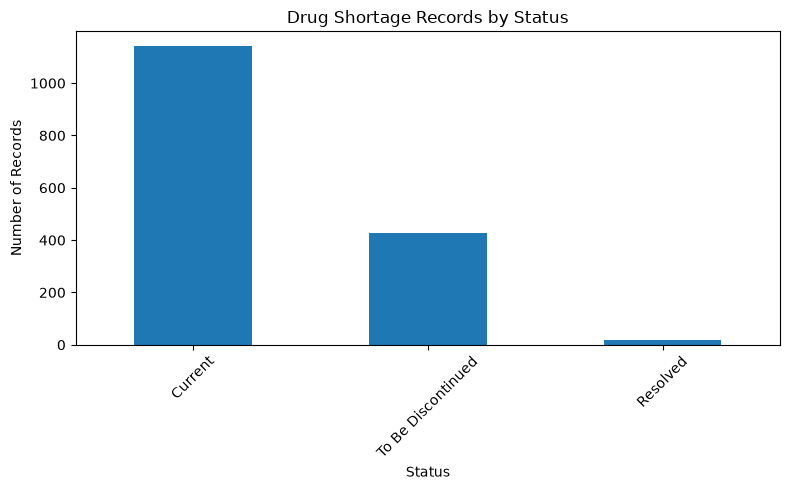

In [57]:
status_counts.plot(
    kind="bar",
    figsize=(8, 5)
)

plt.title("Drug Shortage Records by Status")
plt.xlabel("Status")
plt.ylabel("Number of Records")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## 7. Shortage Reasons

The shortage reason field is examined to identify the recorded causes of drug shortage situations.

In [58]:
shortage_reason_counts = (
    shortages_df["shortage_reason"]
    .value_counts(dropna=False)
)

print(shortage_reason_counts)

shortage_reason
NaN                                                                    1173
Other                                                                   152
Demand increase for the drug                                            109
Shortage of an active ingredient                                         60
Discontinuation of the manufacture of the drug                           49
Delay in shipping of the drug                                            20
Requirements related to complying with good manufacturing practices      18
Shortage of an inactive ingredient component                              4
Regulatory delay                                                          2
Name: count, dtype: int64


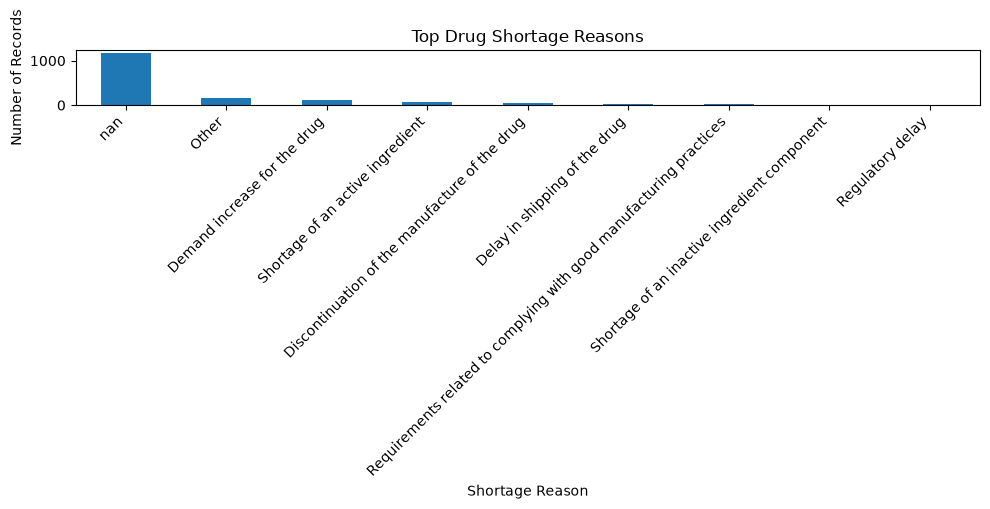

In [59]:
shortage_reason_counts.head(15).plot(
    kind="bar",
    figsize=(10, 5)
)

plt.title("Top Drug Shortage Reasons")
plt.xlabel("Shortage Reason")
plt.ylabel("Number of Records")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

## 8. Therapeutic Categories

Therapeutic categories are analyzed to identify which therapeutic areas are represented among the shortage records.

In [60]:
category_counts = (
    shortages_df["therapeutic_category"]
    .value_counts(dropna=False)
)

print(category_counts.head(20))

therapeutic_category
[Anesthesia]                                                                                                                                         257
[Psychiatry]                                                                                                                                         230
[Cardiovascular]                                                                                                                                     140
[Analgesia/Addiction]                                                                                                                                114
[Anti-Infective]                                                                                                                                      87
[Oncology]                                                                                                                                            79
[Anesthesia, Pediatric]                                      

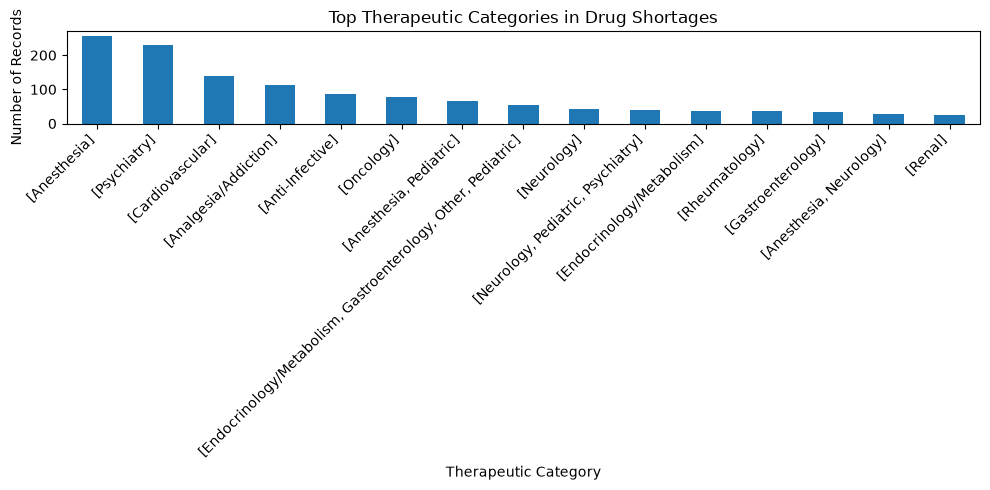

In [61]:
category_counts.head(15).plot(
    kind="bar",
    figsize=(10, 5)
)

plt.title("Top Therapeutic Categories in Drug Shortages")
plt.xlabel("Therapeutic Category")
plt.ylabel("Number of Records")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

## 9. Dosage Forms

The dosage form distribution is examined because different pharmaceutical forms may have different supply characteristics.

In [62]:
dosage_counts = (
    shortages_df["dosage_form"]
    .value_counts(dropna=False)
)

print(dosage_counts.head(20))

dosage_form
Injection                    975
Tablet                       318
Capsule                      133
Solution                      34
NaN                           20
Tablet, Chewable              19
Suppository                   12
Oral Suspension               11
Capsule, Extended Release     10
Irrigant                       9
Ophthalmic Solution            9
Powder, For Solution           8
Oral Solution                  7
Concentrate                    6
Film, Extended Release         5
Spray                          4
Vaginal Gel                    1
Ophthalmic Ointment            1
Transdermal System             1
Oral Powder                    1
Name: count, dtype: int64


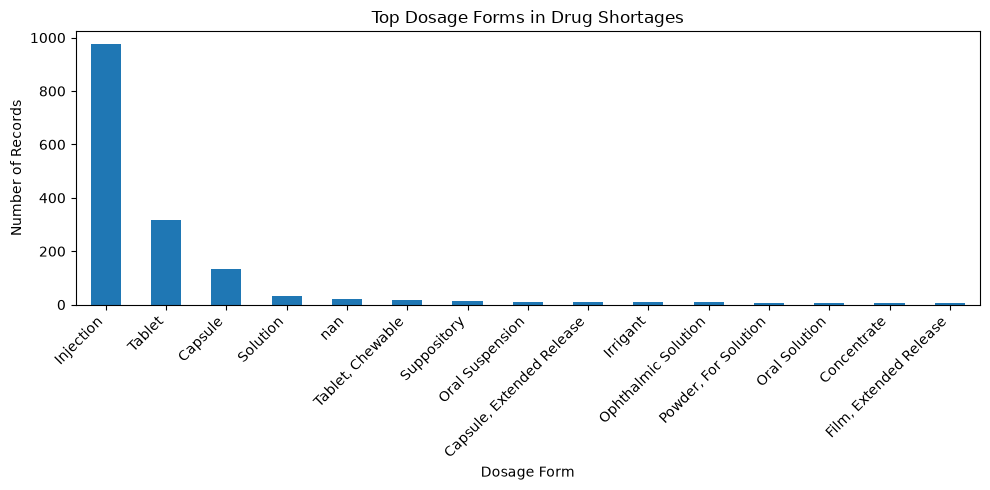

In [63]:
dosage_counts.head(15).plot(
    kind="bar",
    figsize=(10, 5)
)

plt.title("Top Dosage Forms in Drug Shortages")
plt.xlabel("Dosage Form")
plt.ylabel("Number of Records")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

## 10. Generic Drug Names

The generic drug names appearing in the shortage dataset are examined to identify frequently occurring drug substances.

In [64]:
generic_counts = (
    shortages_df["generic_name"]
    .value_counts(dropna=False)
)

print(generic_counts.head(20))

generic_name
Lisdexamfetamine Dimesylate Capsule                                                                                       90
Amphetamine Aspartate Monohydrate, Amphetamine Sulfate, Dextroamphetamine Saccharate, Dextroamphetamine Sulfate Tablet    73
Lidocaine Hydrochloride Injection                                                                                         67
Bupivacaine Hydrochloride Injection                                                                                       62
Dexmedetomidine Hydrochloride Injection                                                                                   59
Ropivacaine Hydrochloride Injection                                                                                       49
Clonazepam Tablet                                                                                                         40
Dextrose Monohydrate 5% Injection                                                                               

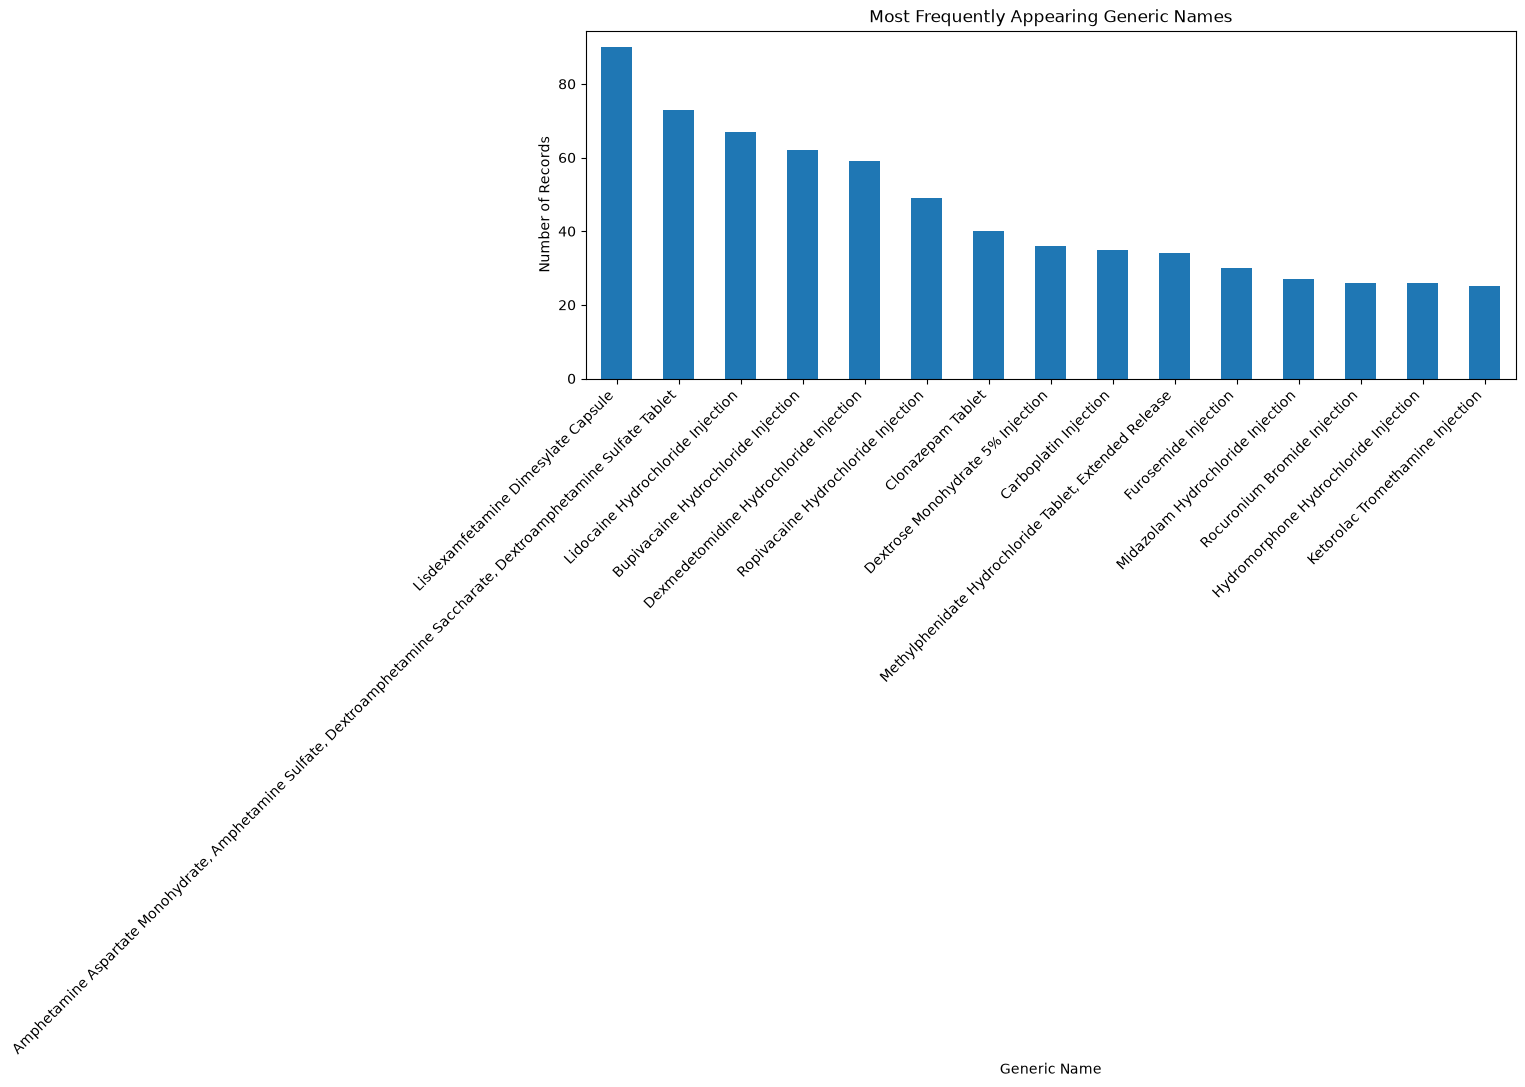

In [80]:
generic_counts.head(15).plot(
    kind="bar",
    figsize=(12, 6)
)

plt.title("Most Frequently Appearing Generic Names")
plt.xlabel("Generic Name")
plt.ylabel("Number of Records")
plt.xticks(rotation=45, ha="right")
plt.subplots_adjust(bottom=0.3)
plt.show()

## 11. Companies

The company distribution in the Drug Shortages dataset is examined to understand the number of shortage records associated with different companies.

In [66]:
company_counts = (
    shortages_df["company_name"]
    .value_counts(dropna=False)
)

print(company_counts.head(20))

company_name
Fresenius Kabi USA, LLC                          184
Hospira, Inc., a Pfizer Company                  179
Hikma Pharmaceuticals USA, Inc.                   97
Teva Pharmaceuticals USA, Inc.                    87
Pfizer Inc.                                       66
Baxter Healthcare                                 65
Eugia US LLC                                      42
Sandoz Inc.                                       38
Accord Healthcare Inc.                            26
Somerset Therapeutics, LLC                        25
Otsuka ICU Medical LLC                            24
Gland Pharma Limited                              23
Mylan Pharmaceuticals Inc., a Viatris Company     22
Amneal Pharmaceuticals                            21
Sun Pharmaceutical Industries, Inc.               21
Takeda Pharmaceuticals USA Inc.                   20
Padagis US LLC                                    20
Endo Pharmaceuticals, Inc.                        20
B. Braun Medical Inc.            

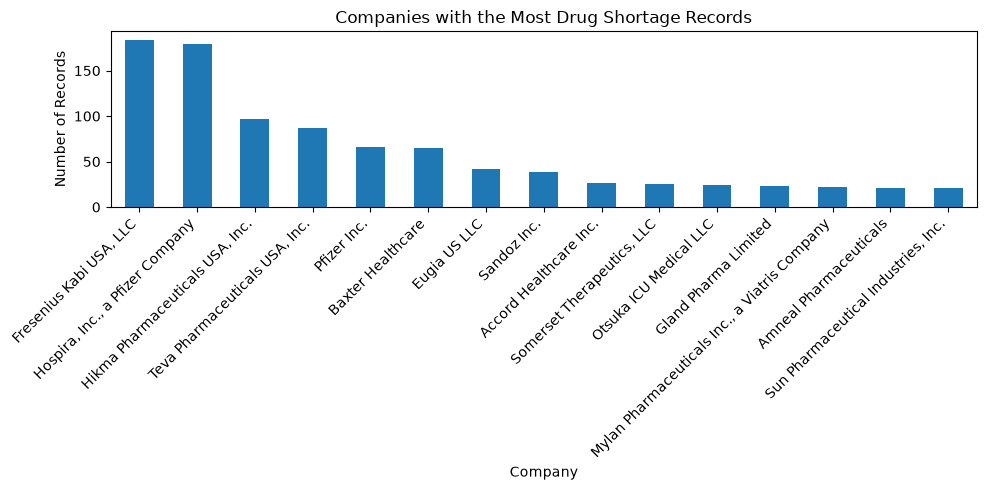

In [67]:
company_counts.head(15).plot(
    kind="bar",
    figsize=(10, 5)
)

plt.title("Companies with the Most Drug Shortage Records")
plt.xlabel("Company")
plt.ylabel("Number of Records")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

## 12. Date Analysis

The posting and update dates are converted into datetime format to examine the temporal distribution of shortage records.

In [68]:
shortages_df["initial_posting_date"] = pd.to_datetime(
    shortages_df["initial_posting_date"],
    errors="coerce"
)

shortages_df["update_date"] = pd.to_datetime(
    shortages_df["update_date"],
    errors="coerce"
)

print(shortages_df[
    ["initial_posting_date", "update_date"]
].dtypes)

initial_posting_date    datetime64[us]
update_date             datetime64[us]
dtype: object


In [69]:
shortages_df["update_year"] = shortages_df["update_date"].dt.year

year_counts = (
    shortages_df["update_year"]
    .value_counts()
    .sort_index()
)

print(year_counts)

update_year
2023       3
2025     126
2026    1458
Name: count, dtype: int64


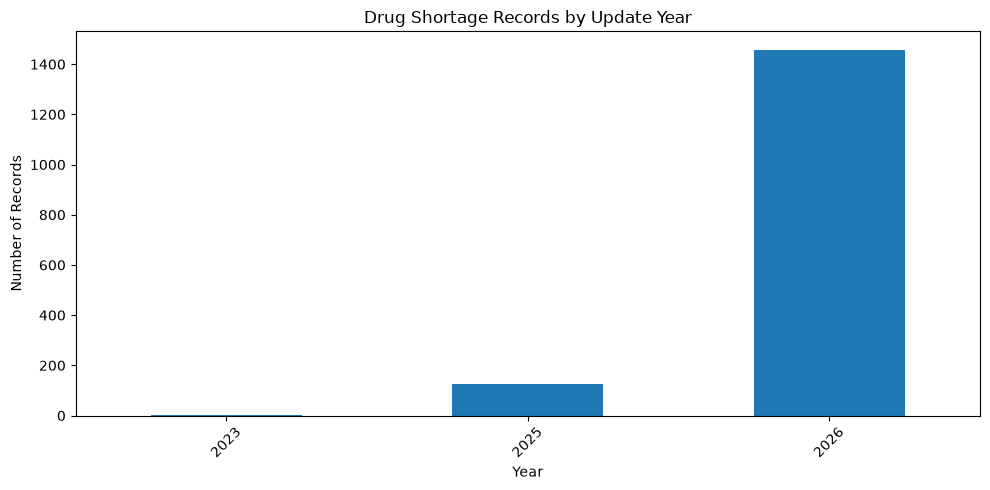

In [70]:
year_counts.plot(
    kind="bar",
    figsize=(10, 5)
)

plt.title("Drug Shortage Records by Update Year")
plt.xlabel("Year")
plt.ylabel("Number of Records")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## 13. Identifier Coverage

The two datasets contain several identifiers that may support integration.

Important identifiers include:

- Application Number
- Product NDC
- Package NDC
- RxCUI
- SPL ID
- Generic Name

The availability of these identifiers is examined before attempting to connect the datasets.

In [71]:
drug_identifiers = [
    "application_number",
    "openfda.application_number",
    "openfda.product_ndc",
    "openfda.package_ndc",
    "openfda.rxcui",
    "openfda.spl_id"
]

print("Drugs@FDA identifier coverage:")

for column in drug_identifiers:
    if column in drugs_df.columns:
        available = drugs_df[column].notna().sum()
        percentage = available / len(drugs_df) * 100

        print(
            f"{column}: {available:,} "
            f"({percentage:.2f}%)"
        )

Drugs@FDA identifier coverage:
application_number: 29,373 (100.00%)
openfda.application_number: 12,148 (41.36%)
openfda.product_ndc: 12,148 (41.36%)
openfda.package_ndc: 12,148 (41.36%)
openfda.rxcui: 11,851 (40.35%)
openfda.spl_id: 12,148 (41.36%)


In [72]:
shortage_identifiers = [
    "package_ndc",
    "openfda.application_number",
    "openfda.product_ndc",
    "openfda.package_ndc",
    "openfda.rxcui",
    "openfda.spl_id"
]

print("Drug Shortages identifier coverage:")

for column in shortage_identifiers:
    if column in shortages_df.columns:
        available = shortages_df[column].notna().sum()
        percentage = available / len(shortages_df) * 100

        print(
            f"{column}: {available:,} "
            f"({percentage:.2f}%)"
        )

Drug Shortages identifier coverage:
package_ndc: 1,587 (100.00%)
openfda.application_number: 1,331 (83.87%)
openfda.product_ndc: 1,359 (85.63%)
openfda.package_ndc: 1,359 (85.63%)
openfda.rxcui: 1,322 (83.30%)
openfda.spl_id: 1,359 (85.63%)


## 14. Dataset Matching

The two datasets will be evaluated for potential integration using shared identifiers.

Exact matching is first examined for identifiers that are directly comparable.

Because some FDA fields contain lists, additional normalization may be required before performing a complete record-level integration.

In [73]:
drug_applications = set(
    drugs_df["application_number"]
    .dropna()
    .astype(str)
)

shortage_applications = set(
    shortages_df["openfda.application_number"]
    .dropna()
    .explode()
    .astype(str)
)

application_matches = (
    drug_applications & shortage_applications
)

print("Matching application numbers:", len(application_matches))

Matching application numbers: 464


In [74]:
drug_product_ndc = set(
    drugs_df["openfda.product_ndc"]
    .dropna()
    .explode()
    .astype(str)
)

shortage_product_ndc = set(
    shortages_df["openfda.product_ndc"]
    .dropna()
    .explode()
    .astype(str)
)

product_ndc_matches = (
    drug_product_ndc & shortage_product_ndc
)

print("Matching product NDCs:", len(product_ndc_matches))

Matching product NDCs: 1229


In [75]:
drug_package_ndc = set(
    drugs_df["openfda.package_ndc"]
    .dropna()
    .explode()
    .astype(str)
)

shortage_package_ndc = set(
    shortages_df["package_ndc"]
    .dropna()
    .astype(str)
)

package_ndc_matches = (
    drug_package_ndc & shortage_package_ndc
)

print("Matching package NDCs:", len(package_ndc_matches))

Matching package NDCs: 1315


In [76]:
drug_rxcui = set(
    drugs_df["openfda.rxcui"]
    .dropna()
    .explode()
    .astype(str)
)

shortage_rxcui = set(
    shortages_df["openfda.rxcui"]
    .dropna()
    .explode()
    .astype(str)
)

rxcui_matches = (
    drug_rxcui & shortage_rxcui
)

print("Matching RxCUIs:", len(rxcui_matches))

Matching RxCUIs: 932


In [77]:
drug_spl = set(
    drugs_df["openfda.spl_id"]
    .dropna()
    .explode()
    .astype(str)
)

shortage_spl = set(
    shortages_df["openfda.spl_id"]
    .dropna()
    .explode()
    .astype(str)
)

spl_matches = (
    drug_spl & shortage_spl
)

print("Matching SPL IDs:", len(spl_matches))

Matching SPL IDs: 512


## 15. Identifier Matching Summary

The number of common identifiers provides an initial indication of how the Drugs@FDA and Drug Shortages datasets can be integrated.

These matching results will guide the data preparation and integration stage of the project.

In [78]:
matching_summary = pd.DataFrame({
    "Identifier": [
        "Application Number",
        "Product NDC",
        "Package NDC",
        "RxCUI",
        "SPL ID"
    ],
    "Matching Values": [
        len(application_matches),
        len(product_ndc_matches),
        len(package_ndc_matches),
        len(rxcui_matches),
        len(spl_matches)
    ]
})

matching_summary

,Identifier,Matching Values
0,Application Number,464
1,Product NDC,1229
2,Package NDC,1315
3,RxCUI,932
4,SPL ID,512


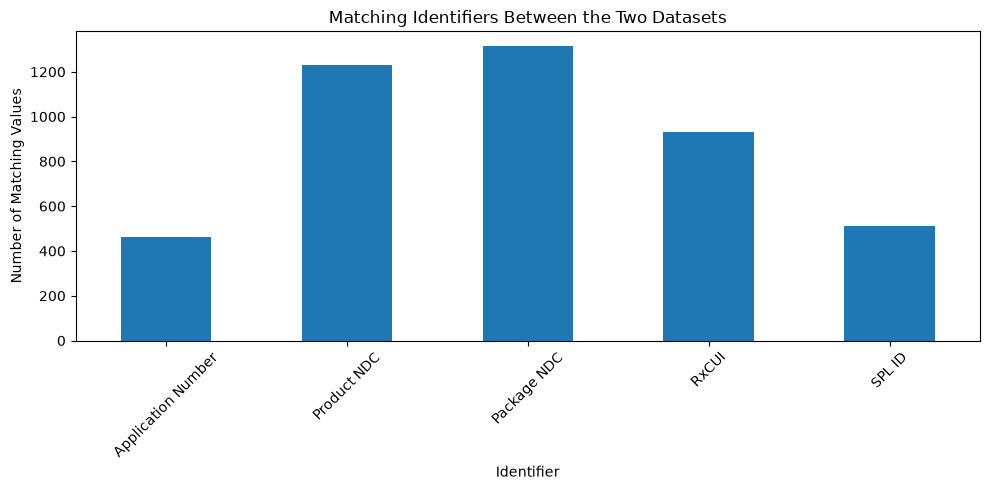

In [79]:
matching_summary.plot(
    x="Identifier",
    y="Matching Values",
    kind="bar",
    figsize=(10, 5),
    legend=False
)

plt.title("Matching Identifiers Between the Two Datasets")
plt.xlabel("Identifier")
plt.ylabel("Number of Matching Values")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# 16. EDA Findings

The exploratory analysis provides an initial understanding of the available FDA data.

Key findings should be documented after running the notebook, including:

- Dataset sizes and structures.
- Important missing-value patterns.
- Duplicate or repeated shortage records.
- Distribution of shortage statuses and reasons.
- Therapeutic categories and dosage forms represented in shortage records.
- Temporal characteristics of shortage records.
- Availability of shared identifiers between Drugs@FDA and Drug Shortages.
- Potential challenges for integrating the datasets.

These findings will be used to define the data preparation and integration strategy for the next stage of the project.

# 17. Data Preparation Considerations

Based on the EDA, the next stage will focus on:

1. Selecting the fields required for the project.
2. Normalizing nested and list-based FDA fields.
3. Standardizing identifiers.
4. Integrating Drugs@FDA and Drug Shortages records.
5. Handling missing values according to their meaning and importance.
6. Representing repeated shortage updates appropriately.
7. Preparing the integrated dataset for shortage risk analysis and decision-support development.